In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train Size:", len(train_dataset))
print("Test Size:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 114MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 30.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 81.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.63MB/s]


Train Size: 60000
Test Size: 10000


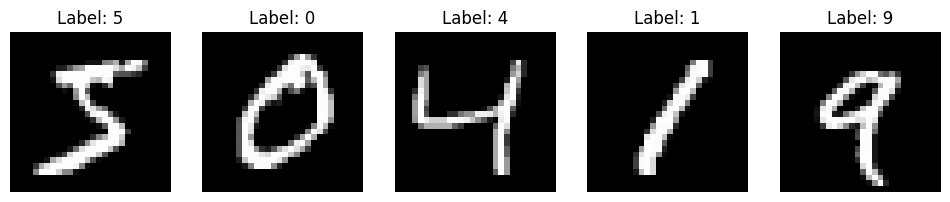

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(12,4))

for i in range(5):
    image, label = train_dataset[i]

    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.show()

In [4]:
class CNNModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.3)


    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [5]:
model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
train_losses = []
test_losses = []

train_acc = []
test_acc = []

In [7]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)


    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    val_epoch_loss = val_loss / len(test_loader)
    val_epoch_acc = 100 * correct / total

    test_losses.append(val_epoch_loss)
    test_acc.append(val_epoch_acc)


    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.2f}%")
    print(f"Test Loss: {val_epoch_loss:.4f}, Test Accuracy: {val_epoch_acc:.2f}%")
    print("----------------------------------")

Epoch [1/10]
Train Loss: 0.2653, Train Accuracy: 91.83%
Test Loss: 0.0700, Test Accuracy: 97.76%
----------------------------------
Epoch [2/10]
Train Loss: 0.0808, Train Accuracy: 97.55%
Test Loss: 0.0422, Test Accuracy: 98.57%
----------------------------------
Epoch [3/10]
Train Loss: 0.0613, Train Accuracy: 98.16%
Test Loss: 0.0414, Test Accuracy: 98.58%
----------------------------------
Epoch [4/10]
Train Loss: 0.0491, Train Accuracy: 98.53%
Test Loss: 0.0332, Test Accuracy: 98.79%
----------------------------------
Epoch [5/10]
Train Loss: 0.0417, Train Accuracy: 98.67%
Test Loss: 0.0336, Test Accuracy: 98.92%
----------------------------------
Epoch [6/10]
Train Loss: 0.0369, Train Accuracy: 98.86%
Test Loss: 0.0341, Test Accuracy: 98.87%
----------------------------------
Epoch [7/10]
Train Loss: 0.0317, Train Accuracy: 98.97%
Test Loss: 0.0299, Test Accuracy: 99.06%
----------------------------------
Epoch [8/10]
Train Loss: 0.0271, Train Accuracy: 99.16%
Test Loss: 0.0309, T

In [8]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print("Final Test Accuracy:", accuracy, "%")

Final Test Accuracy: 98.99 %


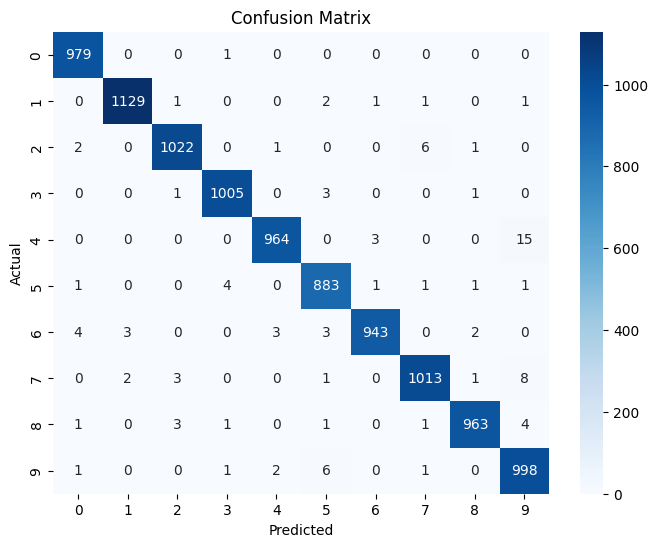

In [9]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

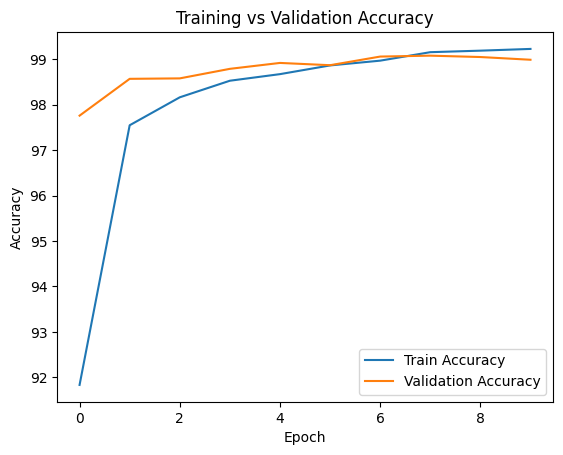

In [10]:
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

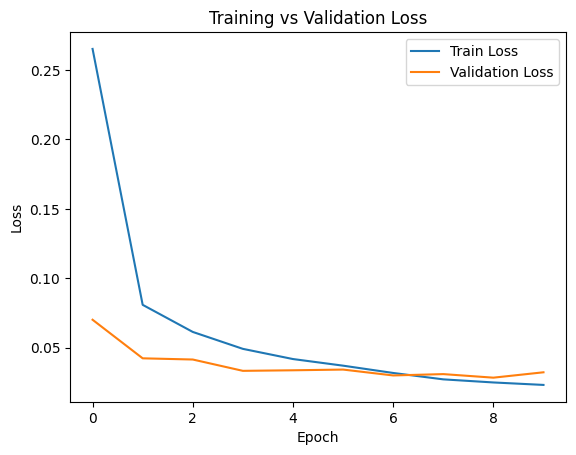

In [11]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

1. Role of Convolution Layers:
Convolution layers automatically extract important image features such as edges, textures, and shapes.

2. Why Pooling is Used:
Pooling reduces image dimensions, lowers computational cost, and helps retain important features.

3. Effect of Increasing Number of Filters:
Increasing filters helps the model learn more complex features, but also increases parameters and training time.

4. What is Overfitting:
Overfitting happens when a model learns training data too specifically and performs poorly on unseen data.
In this model, dropout was used to reduce overfitting. No major overfitting was observed because training and validation accuracy remained close.

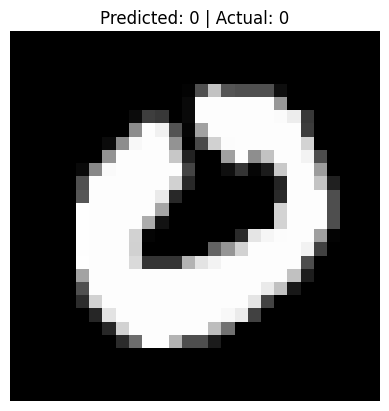

In [12]:
image, label = test_dataset[25]

model.eval()

with torch.no_grad():

    output = model(image.unsqueeze(0).to(device))

    _, pred = torch.max(output, 1)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Predicted: {pred.item()} | Actual: {label}")
plt.axis("off")
plt.show()